# Detecting inherent linearity in transformer models

This Notebook serves to experiment with detecting inherent linearity in Llama models. These experiments will be run on Llama-2-7B to test functionality and provide evidence for a feasibility study as part of the graduation preparation phase. Larger experiments for the final paper(s) will be handled using Python files in this repository.

In [1]:
import torch
from transformers import LlamaForCausalLM, LlamaTokenizer
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import login
from datasets import load_dataset
import re
from tqdm import tqdm
import transformers
import os

# Log in to Hugging Face with hf.login file to access the model
login(token=open("../hf.login").read().strip())

print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print(torch.backends.cuda.matmul.allow_tf32)
print(torch.backends.cudnn.allow_tf32)

CUDA Available: True
GPU: NVIDIA GeForce RTX 4080 SUPER
True
True


In [2]:
# Load the Llama-2-7B model and tokenizer
model = LlamaForCausalLM.from_pretrained("meta-llama/Llama-2-7b-hf")
tokenizer = LlamaTokenizer.from_pretrained("meta-llama/Llama-2-7b-hf")
tokenizer.pad_token = tokenizer.eos_token # Set pad token to eos token if not already set to prevent errors
print("Model and tokenizer loaded.")

Model and tokenizer loaded.


In [3]:
# Load TinyStories dataset

def clean_text(text):
    text = re.sub(r"[^a-zA-Z0-9\s.,!?']", "", text)  # Remove special characters
    text = re.sub(r"\s+", " ", text).strip()  # Remove extra spaces
    return text

# Tokenize and clean the dataset
def preprocess(examples):
    examples["text"] = [clean_text(t) for t in examples["text"]]
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=512)


def load_datasets():
    if not os.path.exists("./data"):
        os.makedirs("./data", exist_ok=True)

    if os.path.exists("./data/tiny_stories_train") and os.path.exists("./data/tiny_stories_val"):
        train_set = load_dataset("roneneldan/TinyStories", split="train").load_from_disk("./data/tiny_stories_train")
        val_set = load_dataset("roneneldan/TinyStories", split="validation").load_from_disk("./data/tiny_stories_val")
        print("Datasets loaded from disk.")
        return train_set, val_set

    train_set = load_dataset("roneneldan/TinyStories", split="train")
    val_set = load_dataset("roneneldan/TinyStories", split="validation")

    train_set = train_set.map(preprocess, batched=True)
    val_set = val_set.map(preprocess, batched=True)
    print("Datasets loaded and preprocessed.")

    # Save to disk for faster loading later
    train_set.save_to_disk("./data/tiny_stories_train")
    val_set.save_to_disk("./data/tiny_stories_val")
    print("Datasets saved to disk.")

    return train_set, val_set

train_dataset, val_dataset = load_datasets()

Datasets loaded from disk.


In [4]:
# Do a forward pass to ensure everything is working
def forward_pass(model, tokenizer, dataset, device='cuda', debug=False):
    model.to(device)
    model.eval()
    if debug:
        print("Preparing inputs for forward pass...")
    inputs = tokenizer(dataset[0]['text'], return_tensors='pt', truncation=True, padding='max_length', max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    if debug:
        print("Inputs prepared. Performing forward pass...")
    with torch.no_grad():
        outputs = model(**inputs)
    if debug:
        print("Forward pass successful.")
    return outputs

# outputs = forward_pass(model, tokenizer, val_dataset, debug=True)
# print("Forward pass output snippet:", outputs.logits[0, :5, :5])

## Visualizing the architecture of Llama-2-7B
To aid with understanding the model architecture, we can visualize the layers and components of Llama-2-7B using a simple diagram.

In [5]:
def visualize_architecture(model):
    for name, module in model.named_modules():
        print(f"{name}: {module.__class__}")

visualize_architecture(model)

: <class 'transformers.models.llama.modeling_llama.LlamaForCausalLM'>
model: <class 'transformers.models.llama.modeling_llama.LlamaModel'>
model.embed_tokens: <class 'torch.nn.modules.sparse.Embedding'>
model.layers: <class 'torch.nn.modules.container.ModuleList'>
model.layers.0: <class 'transformers.models.llama.modeling_llama.LlamaDecoderLayer'>
model.layers.0.self_attn: <class 'transformers.models.llama.modeling_llama.LlamaAttention'>
model.layers.0.self_attn.q_proj: <class 'torch.nn.modules.linear.Linear'>
model.layers.0.self_attn.k_proj: <class 'torch.nn.modules.linear.Linear'>
model.layers.0.self_attn.v_proj: <class 'torch.nn.modules.linear.Linear'>
model.layers.0.self_attn.o_proj: <class 'torch.nn.modules.linear.Linear'>
model.layers.0.mlp: <class 'transformers.models.llama.modeling_llama.LlamaMLP'>
model.layers.0.mlp.gate_proj: <class 'torch.nn.modules.linear.Linear'>
model.layers.0.mlp.up_proj: <class 'torch.nn.modules.linear.Linear'>
model.layers.0.mlp.down_proj: <class 'torc

## Computing the mean of preactivations per ReLU layer
"**Mean of preactivations $\bar{p}^l$** We denote the distribution of inputs $z$ to a nonlinear activation function $f(z)$ as the preactivations. For each activation function/node, we compute the mean of the preactivations, and then we compute another mean of these values per layer $l$: $\bar{p}^l= \frac{1}{M}\sum_{i=1}^M \left(\frac{1}{N}\sum_{s=1}^N z_{s,i}^l\right)$,
with $M$ the number of nodes in layer $l$ and $N$ the number of samples, and $z_{s,i}^l$ the preactivation value for sample $s$ at node $i$ at layer $l$. We compute this value through randomly selecting 500 samples of the input data instead of the whole dataset, which significantly reduces the computational cost." (Pinson et al., 2024, p. 3).

In case there is BatchNormalization applied between the convolution and the activation function, the mean of the preactivations will be approximately 0, due to the normalization. However, BN has two learned parameters per channel, namely a scaling and a shifting parameter. The shifting parameter can be used to recover the mean of the preactivations before BN. Therefore, in case of BN, we will use the shifting parameter as the mean of the preactivations. (Pinson et al., 2024)

In [7]:
def retrieve_mean_preactivations(model, tokenizer, dataset, device='cuda', save=False):
    """Compute the mean of preactivations for each activation layer in the model. Function does this by computing the mean preactivation values over a set of input data. For Llama with RMS normalization before and after self-attention, we can't retrieve preactivations from normalization parameters. Thus, we must calculate the mean of the input of the normalization before activation named 'model.layers.n.post_attention_layernorm' and 'model.layers.n.mlp.act_fn' where n is the layer number.
    Args:
        model: The neural network model.
        tokenizer: The tokenizer for the model.
        dataset: The dataset to compute preactivations on.
        device: Device to run the computations on.

    Returns:
        dict: A dictionary with layer names as keys and mean preactivation values as values.
    """
    save_path = f"./mean_preactivations_llama2_7b.pt"
    if save and os.path.exists(save_path):
        print("Loading mean preactivations from disk...")
        return torch.load(save_path)

    model.to(device)
    model.eval()
    activation_layers = []

    # Storage
    channel_sums = {}     # name -> tensor [D]
    sample_counts = {}    # name -> int
    hooks = []

    print("Identifying activation layers and registering hooks...")
    # Identify activation layers
    for name, module in model.named_modules():
        if re.match(r'model\.layers\.\d+\.mlp\.act_fn', name) or re.match(r'model\.layers\.\d+\.post_attention_layernorm', name):
            activation_layers.append((name, module))
    print("Identified layers, setting hooks...")
    # Define hook to capture preactivations
    def get_preactivation_hook(name):
        def hook(module, input, output):
            # input[0] shape: [B, T, D]
            x = input[0].detach()

            B, T, D = x.shape

            # Mean over batch + sequence, keep hidden dimension
            per_dim_batch_mean = x.mean(dim=(0, 1))  # [D]

            if name not in channel_sums:
                channel_sums[name] = per_dim_batch_mean * (B * T)
                sample_counts[name] = B * T
            else:
                channel_sums[name] += per_dim_batch_mean * (B * T)
                sample_counts[name] += B * T

        return hook

    # Register hooks
    for name, module in activation_layers:
        hooks.append(module.register_forward_hook(get_preactivation_hook(name)))
    print("Hooks registered. Performing forward passes...")
    # Forward pass through the data
    with torch.no_grad():
        for i in tqdm(range(30), desc="Processing samples for preactivations", leave=False):
            inputs = tokenizer(dataset[i]['text'], return_tensors='pt', truncation=True, padding='max_length', max_length=512)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            model(**inputs)
    print("Forward passes complete. Computing mean preactivations...")

    # Compute mean preactivations
    mean_preactivations = {}
    for name in channel_sums:
        per_dim_mean = channel_sums[name] / sample_counts[name]  # [D]
        mean_preactivations[name] = per_dim_mean.mean().item()   # scalar

    print("Mean preactivations computed.")
    # Remove hooks
    for hook in hooks:
        hook.remove()
    print("Hooks removed.")

    if save:
        torch.save(mean_preactivations, save_path)
        print("Mean preactivations saved to disk.")

    return mean_preactivations


mean_preactivations = retrieve_mean_preactivations(model, tokenizer, val_dataset, save=True)
print("Mean preactivations per layer:")
for layer, mean_val in mean_preactivations.items():
    print(f"{layer}: {mean_val}")

Mean preactivations computed.
Hooks removed.
Mean preactivations saved to disk.
Mean preactivations per layer:
model.layers.0.post_attention_layernorm: 0.0002595959522295743
model.layers.0.mlp.act_fn: -0.025787563994526863
model.layers.1.post_attention_layernorm: 0.0003377649700269103
model.layers.1.mlp.act_fn: -0.051927123218774796
model.layers.2.post_attention_layernorm: 0.0005598971620202065
model.layers.2.mlp.act_fn: -0.05247614160180092
model.layers.3.post_attention_layernorm: 0.0006965644424781203
model.layers.3.mlp.act_fn: -0.058733586221933365
model.layers.4.post_attention_layernorm: 0.0009516386780887842
model.layers.4.mlp.act_fn: -0.08834380656480789
model.layers.5.post_attention_layernorm: -6.195227615535259e-05
model.layers.5.mlp.act_fn: -0.10974007844924927
model.layers.6.post_attention_layernorm: 0.0008427342399954796
model.layers.6.mlp.act_fn: -0.11251381039619446
model.layers.7.post_attention_layernorm: 0.0004720711149275303
model.layers.7.mlp.act_fn: -0.137286901473999

In [8]:
# Map the preactivations of the activations to the preceding attention layer for clarity
mapped_mean_preactivations = {}
for layer_name, mean_val in mean_preactivations.items():
    match = re.match(r'model\.layers\.(\d+)\.mlp\.act_fn', layer_name)
    if match:
        layer_num = match.group(1)
        mapped_mean_preactivations[f'model.layers.{layer_num}.self_attn'] = mean_val
        print(f"Mapped model.layers.{layer_num}.self_attn with mean preactivation {mean_val}")

Mapped model.layers.0.self_attn with mean preactivation -0.025787563994526863
Mapped model.layers.1.self_attn with mean preactivation -0.051927123218774796
Mapped model.layers.2.self_attn with mean preactivation -0.05247614160180092
Mapped model.layers.3.self_attn with mean preactivation -0.058733586221933365
Mapped model.layers.4.self_attn with mean preactivation -0.08834380656480789
Mapped model.layers.5.self_attn with mean preactivation -0.10974007844924927
Mapped model.layers.6.self_attn with mean preactivation -0.11251381039619446
Mapped model.layers.7.self_attn with mean preactivation -0.13728690147399902
Mapped model.layers.8.self_attn with mean preactivation -0.11505090445280075
Mapped model.layers.9.self_attn with mean preactivation -0.12234443426132202
Mapped model.layers.10.self_attn with mean preactivation -0.11998369544744492
Mapped model.layers.11.self_attn with mean preactivation -0.13198116421699524
Mapped model.layers.12.self_attn with mean preactivation -0.13100014626

## Pruning the model and identifying the pruned layers
To see whether pruning strategies target the layers that are more linear, we will prune the model using a couple methods. First, we will use a pruning method without layer-specific pruning ratios to see if the pruning method will target linear layers. A simple L1 pruning strategy will be used for initial results Later, pruning methods will be chosen from literature such that there is a clear scientific basis for the pruning method.

In [11]:
@torch.no_grad()
def l1_prune_llama_ffn_global(model, target_prune_ratio=0.2, layers_to_prune=None):
    """
    Structured L1 pruning of FFN intermediate dimensions for LLaMA,
    aiming to achieve target_prune_ratio for the entire model, not per layer.
    """

    model.eval()
    layers = model.model.layers
    if layers_to_prune is None:
        layers_to_prune = range(len(layers))

    # -----------------------------
    # 1. Gather all FFN importance values
    # -----------------------------
    all_importances = []
    layer_ffn_shapes = []
    for layer_idx in layers_to_prune:
        block = layers[layer_idx]
        mlp = block.mlp
        gate = mlp.gate_proj
        ffn_dim = gate.out_features
        importance = torch.norm(gate.weight, p=1, dim=1)  # [ffn_dim]
        all_importances.append(importance)
        layer_ffn_shapes.append(ffn_dim)

    # Flatten all importances to compute global pruning threshold
    all_importances_flat = torch.cat(all_importances)
    total_channels = all_importances_flat.numel()
    num_prune_total = int(target_prune_ratio * total_channels)

    if num_prune_total == 0:
        return model, {}

    # -----------------------------
    # 2. Compute global pruning threshold
    # -----------------------------
    prune_threshold = torch.topk(all_importances_flat, num_prune_total, largest=False).values.max()

    # -----------------------------
    # 3. Prune each layer based on threshold
    # -----------------------------
    pruned_info = {}
    for layer_idx, ffn_dim, importance in zip(layers_to_prune, layer_ffn_shapes, all_importances):
        block = layers[layer_idx]
        mlp = block.mlp
        gate = mlp.gate_proj
        up   = mlp.up_proj
        down = mlp.down_proj

        # Indices to keep: importance > threshold
        keep_idx = torch.nonzero(importance > prune_threshold, as_tuple=False).squeeze(-1)
        if keep_idx.numel() == 0:
            # Avoid empty layer
            keep_idx = torch.tensor([torch.argmax(importance)], device=importance.device)

        # Slice weights
        gate.weight = torch.nn.Parameter(gate.weight[keep_idx, :])
        up.weight   = torch.nn.Parameter(up.weight[keep_idx, :])
        down.weight = torch.nn.Parameter(down.weight[:, keep_idx])

        if gate.bias is not None:
            gate.bias = torch.nn.Parameter(gate.bias[keep_idx])
        if up.bias is not None:
            up.bias = torch.nn.Parameter(up.bias[keep_idx])
        if down.bias is not None:
            down.bias = torch.nn.Parameter(down.bias)

        # Update metadata
        new_ffn_dim = keep_idx.numel()
        gate.out_features = new_ffn_dim
        up.out_features   = new_ffn_dim
        down.in_features  = new_ffn_dim

        pruned_info[f"layer_{layer_idx}"] = {
            "ffn_before": ffn_dim,
            "ffn_after": new_ffn_dim,
            "pruned_ratio": 1.0 - new_ffn_dim / ffn_dim,
        }

    # Report effective total prune ratio
    total_pruned = sum(info["ffn_before"] - info["ffn_after"] for info in pruned_info.values())
    pruned_info["total_pruned_ratio"] = total_pruned / total_channels

    return model, pruned_info

pruned_model, layer_pruning_ratios = l1_prune_llama_ffn_global(model, target_prune_ratio=0.3)

print("Layer pruning ratios versus mean preactivations:")
for layer, info in layer_pruning_ratios.items():
    if layer != "total_pruned_ratio":
        print(f"{layer}: Pruned Ratio = {info['pruned_ratio']}, mean preactivation = {mapped_mean_preactivations.get(f'model.layers.{layer.split('_')[1]}.self_attn', 'N/A')}")

# Calculate pruning ratio over whole model
total_pruned_ratio = layer_pruning_ratios["total_pruned_ratio"]
print(f"Total pruning ratio over the whole model: {total_pruned_ratio}")

Layer pruning ratios versus mean preactivations:
layer_0: Pruned Ratio = 0.3046594982078853, mean preactivation = -0.025787563994526863
layer_1: Pruned Ratio = 0.611073598919649, mean preactivation = -0.051927123218774796
layer_2: Pruned Ratio = 0.8137915287133235, mean preactivation = -0.05247614160180092
layer_3: Pruned Ratio = 0.5813848412967355, mean preactivation = -0.058733586221933365
layer_4: Pruned Ratio = 0.3941425546930134, mean preactivation = -0.08834380656480789
layer_5: Pruned Ratio = 0.2870567598045358, mean preactivation = -0.10974007844924927
layer_6: Pruned Ratio = 0.21764046343590382, mean preactivation = -0.11251381039619446
layer_7: Pruned Ratio = 0.17503624621062341, mean preactivation = -0.13728690147399902
layer_8: Pruned Ratio = 0.17969661610268373, mean preactivation = -0.11505090445280075
layer_9: Pruned Ratio = 0.20366795366795365, mean preactivation = -0.12234443426132202
layer_10: Pruned Ratio = 0.1895514693246262, mean preactivation = -0.1199836954474449

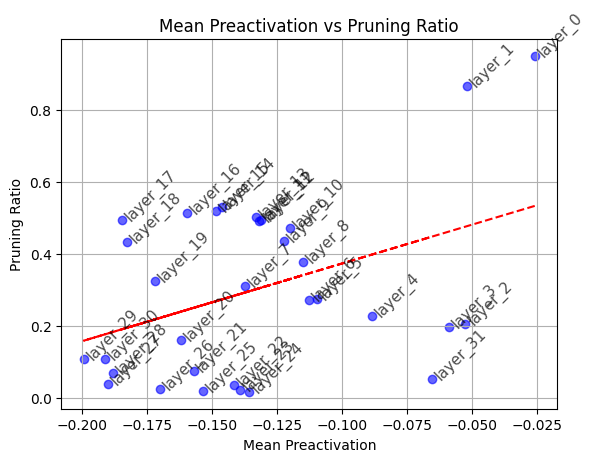

In [10]:
import pandas as pd

# Keep pruning ratios and preactivations where both exist for that layer
data = {
    "Layer": [],
    "Mean_Preactivation": [],
    "Pruning_Ratio": []
}
for layer_key, info in layer_pruning_ratios.items():
    if layer_key.startswith("layer_"):
        layer_num = layer_key.split("_")[1]
        mean_preact_key = f"model.layers.{layer_num}.self_attn"
        if mean_preact_key in mapped_mean_preactivations:
            data["Layer"].append(layer_key)
            data["Mean_Preactivation"].append(mapped_mean_preactivations[mean_preact_key])
            data["Pruning_Ratio"].append(info["pruned_ratio"])
df = pd.DataFrame(data)

# Use matplotlib to create a scatter plot of mean preactivations vs pruning ratios and fit a linear regression line
plt.scatter(df["Mean_Preactivation"], df["Pruning_Ratio"], color='blue', alpha=0.6)
plt.title("Mean Preactivation vs Pruning Ratio")
plt.xlabel("Mean Preactivation")
plt.ylabel("Pruning Ratio")

# Label the points with layer names at 45 degree angle
for i, row in df.iterrows():
    plt.text(row["Mean_Preactivation"], row["Pruning_Ratio"], row["Layer"], fontsize=11, alpha=0.7, rotation=45)

# Fit and plot a trend line
z = np.polyfit(df["Mean_Preactivation"], df["Pruning_Ratio"], 1)
p = np.poly1d(z)
plt.plot(df["Mean_Preactivation"], p(df["Mean_Preactivation"]), "r--")
plt.grid()
plt.show()